## Understanding the Dataset

With the exception of **Time/Transaction** and **Amount**, the remaining features are anonymized for privacy and have already been **scaled/standardized**. This limits how much we can rely on real-world “business logic” during EDA and changes what we should (and shouldn’t) conclude from inspection.

### Implications for EDA
Because the features are not interpretable, some common checks become harder or only partially possible:

- **Missingness assumptions (MCAR/MAR/MNAR):** We can detect whether values are missing, but we cannot easily justify *why* they are missing based on feature meaning.
- **Categorical encoding checks:** Since features are anonymized and already transformed, we cannot confidently identify which features were originally categorical or how they were encoded.
- **Data leakage checks via domain logic:** We can still look for leakage statistically (e.g., unusually strong associations with the target or time-based artifacts), but we can’t validate it using real-world feature behavior.

---

## Quick Data Quality Summary

- **Transaction amounts are relatively small on average.** The mean transaction amount is approximately **$88**.
- **No missing values detected.** There are no `null` / `NaN` entries, so no imputation is required.
- **Severe class imbalance.** **Non-fraud** transactions represent about **99.83%**, while **fraud** transactions account for roughly **0.17%** of the dataset.


### 1. Sanity check

In [2]:
import pandas as pd
from pathlib import Path

ROOT_DIR = Path.cwd().parent
SRC = ROOT_DIR / 'data' / 'creditcard.csv'

original_df = pd.read_csv(SRC)

In [4]:
original_df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
original_df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [7]:
original_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [9]:
# Check for missing values
original_df.isnull().sum().max()

0

In [12]:
# Creating target variable distribution dataframe
df_target = original_df['Class']
df_target_plot = df_target.value_counts().to_frame()
df_target_plot['Percentage'] = round((df_target_plot['count'] / len(df_target)) * 100, 2)
print(df_target_plot)

        count  Percentage
Class                    
0      284315       99.83
1         492        0.17


*Note:* Notice how imbalanced is our dataset!

### Drift check

C:\Users\User\AppData\Local\Temp\ipykernel_15788\2770988231.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df_sorted.groupby("time_bin")['Class'].mean() * 100


<function matplotlib.pyplot.show(close=None, block=None)>

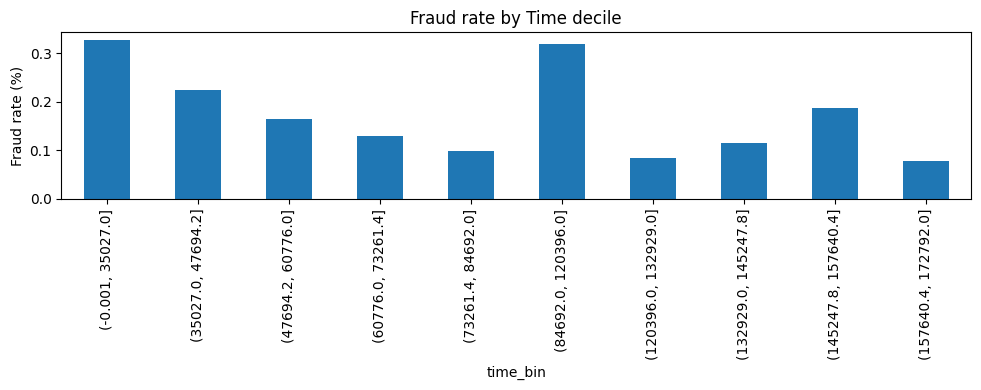

In [19]:
# Fraud rate by Time decile

import pandas as pd
import matplotlib.pyplot as plt

df_sorted = original_df.sort_values('Time')
df_sorted['time_bin'] = pd.qcut(df_sorted['Time'], q=10, duplicates='drop')

summary = df_sorted.groupby("time_bin")['Class'].mean() * 100

plt.figure(figsize=(10, 4))
summary.plot(kind='bar')
plt.ylabel('Fraud rate (%)')
plt.title('Fraud rate by Time decile')
plt.tight_layout()
plt.show

*Interpretation of the Figure:* As you can see, Time decile doesn't tell much about fraud pattern.

### Important Feature check (Time & Amount)

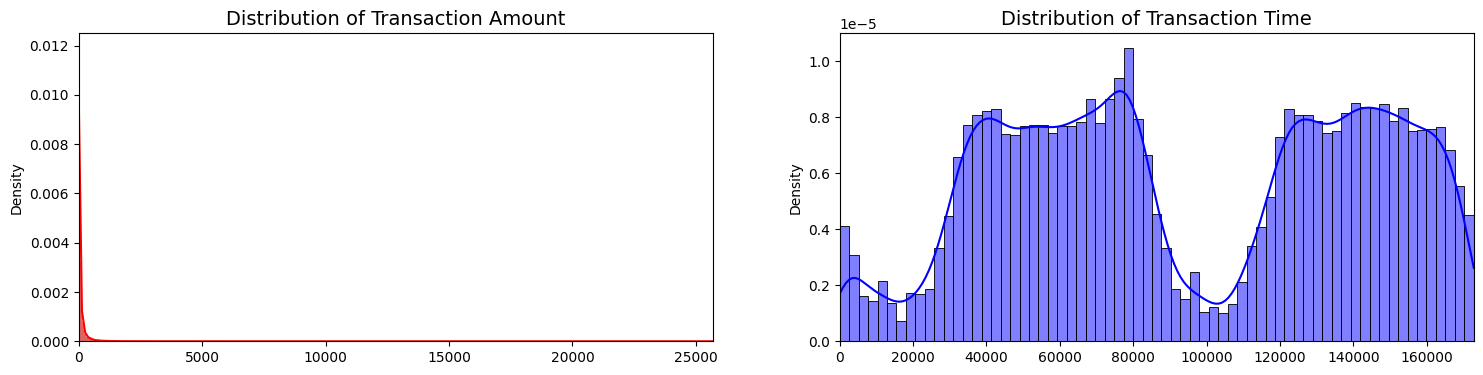

In [20]:
# Plotting Distributions of Amount and Time

import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(1, 2, figsize=(18, 4))

amount_val = original_df['Amount'].values
time_val = original_df['Time'].values

sns.histplot(amount_val, ax=ax[0], color='r', kde=True, stat='density')
ax[0].set_title('Distribution of Transaction Amount', fontsize=14)
ax[0].set_xlim([min(amount_val), max(amount_val)])
ax[0].set_ylim([0, 0.0125])

sns.histplot(time_val, ax=ax[1], color='b', kde=True, stat='density')
ax[1].set_title('Distribution of Transaction Time', fontsize=14)
ax[1].set_xlim([min(time_val), max(time_val)])

plt.show()

In [18]:
# Inspecting for some patterns from amount and time by classes

def summarize_by_class(col):
    g = original_df.groupby("Class")[col]
    out = g.agg(['mean', 'median', 'min', 'max'])
    out['p95'] = g.quantile(0.95)
    out['p99'] = g.quantile(0.99)
    return out

print(summarize_by_class('Amount'))
print(summarize_by_class('Time'))

             mean  median  min       max      p95        p99
Class                                                       
0       88.291022   22.00  0.0  25691.16  364.409  1016.9664
1      122.211321    9.25  0.0   2125.87  640.905  1357.4279
               mean   median    min       max        p95        p99
Class                                                              
0      94838.202258  84711.0    0.0  172792.0  164149.30  170564.00
1      80746.806911  75568.5  406.0  170348.0  156696.25  167500.36


*Conclusion:* 
- Max Amount for fraud is 2125.87, which is relatively less from non-fraud, it might suggest that large amount is not a indicator of fraud. Also, 95% percent of the fraud amount falls in 640$, which might indicate that short amount of credit card fraud is the main issue for us
- About Time column, it is clearly seen as not a good indicator of fraud. The minimum time of transactions for fraud is 406, which can be understood by common sense.

### Scaling Time & Amount column

In [34]:
from sklearn.preprocessing import RobustScaler

rob_scaler = RobustScaler()

scaled_df = original_df
scaled_df['scaled_amount'] = rob_scaler.fit_transform(scaled_df['Amount'].values.reshape(-1, 1))
scaled_df['scaled_time'] = rob_scaler.fit_transform(scaled_df['Time'].values.reshape(-1, 1))
scaled_df.drop(['Time', 'Amount'], axis=1, inplace=True)

In [37]:
cols = scaled_df.columns.tolist()
front = ['scaled_amount', 'scaled_time']
scaled_df = scaled_df[front + [c for c in cols if c not in front]]

### Correlation & Redundancy

<function matplotlib.pyplot.show(close=None, block=None)>

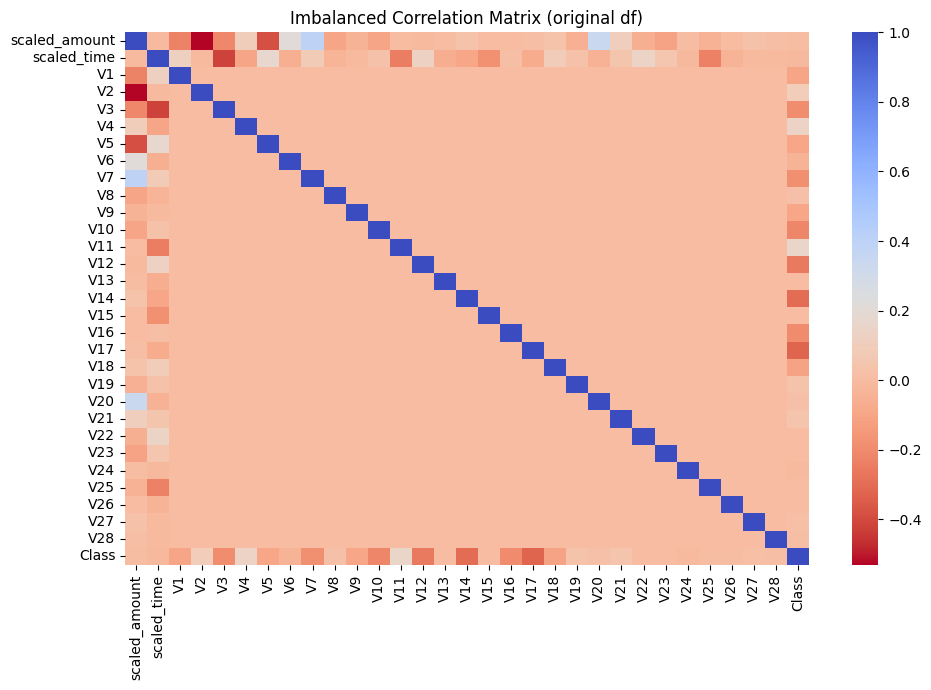

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

corr = scaled_df.corr(numeric_only=True)
plt.figure(figsize=(10, 7))
sns.heatmap(corr, cmap='coolwarm_r')
plt.title('Imbalanced Correlation Matrix (original df)')
plt.tight_layout()
plt.show

In [40]:
# Check if two features are 95% correlated, if so drop the column

import numpy as np
import pandas as pd

def drop_highly_correlated_keep_target(
    df: pd.DataFrame,
    target_col: str,
    threshold: float = 0.95,
    method: str = "pearson",
):
    """
    Drops one of any two features whose absolute correlation >= threshold,
    keeping the feature that is MORE correlated with the target (absolute).

    Returns:
        df_reduced: DataFrame with redundant columns removed
        dropped: list of dropped column names
        decisions: DataFrame log of (kept, dropped, feature_corr, kept_target_corr, dropped_target_corr)
    """
    if target_col not in df.columns:
        raise ValueError(f"target_col '{target_col}' not found in df.columns")

    # Use only numeric columns for correlation
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if target_col not in numeric_cols:
        raise ValueError(
            f"target_col '{target_col}' must be numeric (e.g., 0/1). "
            "If it's categorical, map it to numbers first."
        )

    feature_cols = [c for c in numeric_cols if c != target_col]
    if len(feature_cols) < 2:
        return df.copy(), [], pd.DataFrame(columns=[
            "kept", "dropped", "abs_feature_corr", "kept_abs_target_corr", "dropped_abs_target_corr"
        ])

    # Correlation among features
    corr = df[feature_cols].corr(method=method).abs()

    # Correlation of each feature with target
    target_corr = df[feature_cols + [target_col]].corr(method=method)[target_col].abs()
    target_corr = target_corr.drop(index=target_col).fillna(0.0)

    # Get upper triangle pairs (avoid duplicates and self-correlation)
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    pairs = (
        upper.stack()
        .reset_index()
        .rename(columns={"level_0": "f1", "level_1": "f2", 0: "abs_feature_corr"})
        .sort_values("abs_feature_corr", ascending=False)
    )

    dropped = set()
    decisions = []

    for f1, f2, cval in pairs.itertuples(index=False):
        if cval < threshold:
            break
        if f1 in dropped or f2 in dropped:
            continue

        t1 = float(target_corr.get(f1, 0.0))
        t2 = float(target_corr.get(f2, 0.0))

        # Drop the one LESS related to the target
        if t1 > t2:
            keep, drop = f1, f2
        elif t2 > t1:
            keep, drop = f2, f1
        else:
            # Tie-breaker: drop f2 (deterministic)
            keep, drop = f1, f2

        dropped.add(drop)
        decisions.append({
            "kept": keep,
            "dropped": drop,
            "abs_feature_corr": float(cval),
            "kept_abs_target_corr": float(max(t1, t2)),
            "dropped_abs_target_corr": float(min(t1, t2)),
        })

    df_reduced = df.drop(columns=list(dropped), errors="ignore")
    decisions_df = pd.DataFrame(decisions)

    return df_reduced, sorted(dropped), decisions_df


df_reduced, dropped_cols, log = drop_highly_correlated_keep_target(original_df, target_col="Class", threshold=0.95)
print("Dropped:", dropped_cols)
display(log.head(20))


Dropped: []


""


In [41]:
# Correlation of features with the target by number
corr_with_class = (
    original_df.corr(numeric_only=True)["Class"]
    .drop("Class")
    .sort_values()
)

print("Most negative:\n", corr_with_class.head(5))
print("\nMost positive:\n", corr_with_class.tail(5))

Most negative:
 V17   -0.326481
V14   -0.302544
V12   -0.260593
V10   -0.216883
V16   -0.196539
Name: Class, dtype: float64

Most positive:
 V19    0.034783
V21    0.040413
V2     0.091289
V4     0.133447
V11    0.154876
Name: Class, dtype: float64


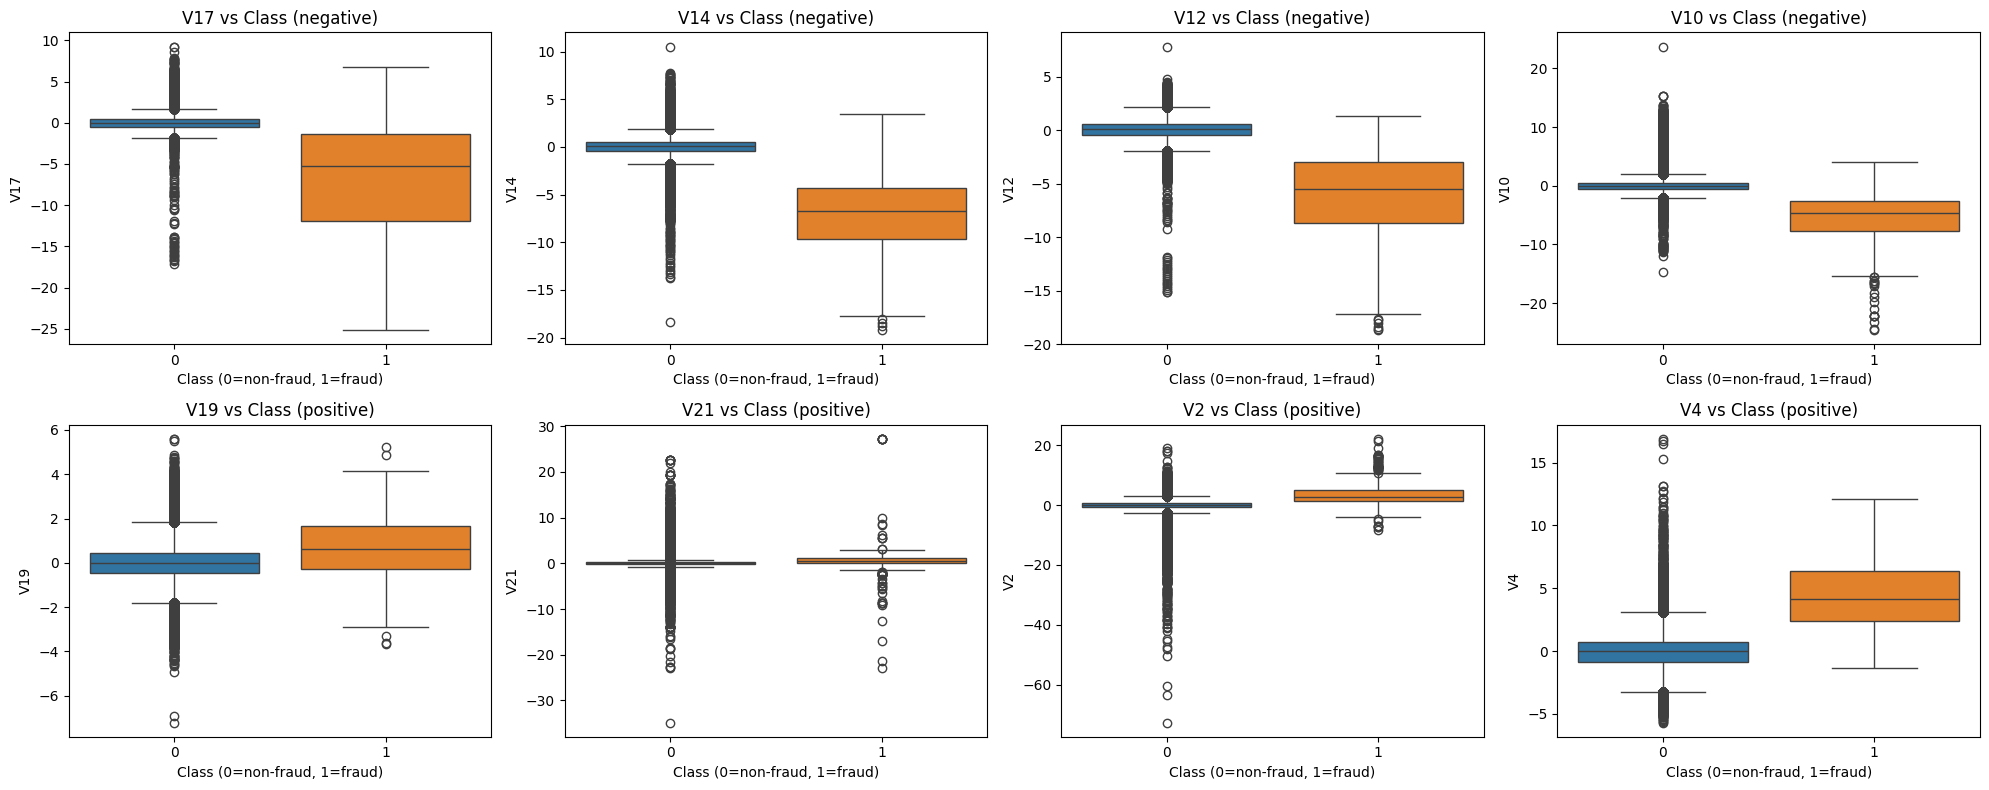

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

MOST_NEGATIVE = ['V17', 'V14', 'V12', 'V10']
MOST_POSITIVE = ['V19', 'V21', 'V2', 'V4']

# Two colors: Class 0 and Class 1
colors = {0: "#1f77b4", 1: "#ff7f0e"}  # blue, orange

def plot_class_boxplots(df, neg_features, pos_features, palette=colors):
    """
    Draws boxplots of each feature vs Class (0/1) with Seaborn v0.14+ compatible palette usage.
    Top row: neg_features
    Bottom row: pos_features
    """
    if "Class" not in df.columns:
        raise ValueError("DataFrame must contain a 'Class' column (0/1).")

    # Ensure Class is clean ints (helps palette mapping)
    df = df.copy()
    df["Class"] = df["Class"].astype(int)

    # Keep only existing features
    neg = [c for c in neg_features if c in df.columns]
    pos = [c for c in pos_features if c in df.columns]

    missing_feats = [c for c in (neg_features + pos_features) if c not in df.columns]
    if missing_feats:
        print(f"Warning: skipping missing features: {missing_feats}")

    ncols = max(len(neg), len(pos))
    fig, axes = plt.subplots(nrows=2, ncols=ncols, figsize=(5 * ncols, 8), squeeze=False)

    def _box(ax, feat, title):
        sns.boxplot(
            data=df,
            x="Class",
            y=feat,
            hue="Class",          # <-- fixes the FutureWarning
            palette=palette,
            ax=ax
        )
        # Remove redundant legend (same as x-axis)
        if ax.get_legend() is not None:
            ax.get_legend().remove()

        ax.set_title(title)
        ax.set_xlabel("Class (0=non-fraud, 1=fraud)")

    # Row 1: negative
    for i in range(ncols):
        ax = axes[0, i]
        if i < len(neg):
            feat = neg[i]
            _box(ax, feat, f"{feat} vs Class (negative)")
        else:
            ax.axis("off")

    # Row 2: positive
    for i in range(ncols):
        ax = axes[1, i]
        if i < len(pos):
            feat = pos[i]
            _box(ax, feat, f"{feat} vs Class (positive)")
        else:
            ax.axis("off")

    plt.tight_layout()
    plt.show()

# Usage:
plot_class_boxplots(scaled_df, MOST_NEGATIVE, MOST_POSITIVE)


### TSNE, PCA, TruncatedSVD
*Note:* In a professional setting, the figures created after dimensionality reduction aren't informative. These are just for to see if the data can be used for training and result the noticeable outcome.

In [45]:
# Random Under Sampling for the figures

import pandas as pd

scaled_df_shuf = scaled_df.sample(frac=1, random_state=42).reset_index(drop=True)

fraud_df = scaled_df_shuf[scaled_df_shuf['Class'] == 1]
non_fraud_df = scaled_df_shuf[scaled_df_shuf['Class'] == 0].sample(n=len(fraud_df), random_state=42)

sampled_df = pd.concat([fraud_df, non_fraud_df], axis=0).sample(frac=1, random_state=42).reset_index(drop=True)

t-SNE (3D) took 19.09 s
PCA (3D) took 0.03 s
TruncatedSVD (3D) took 0.01 s


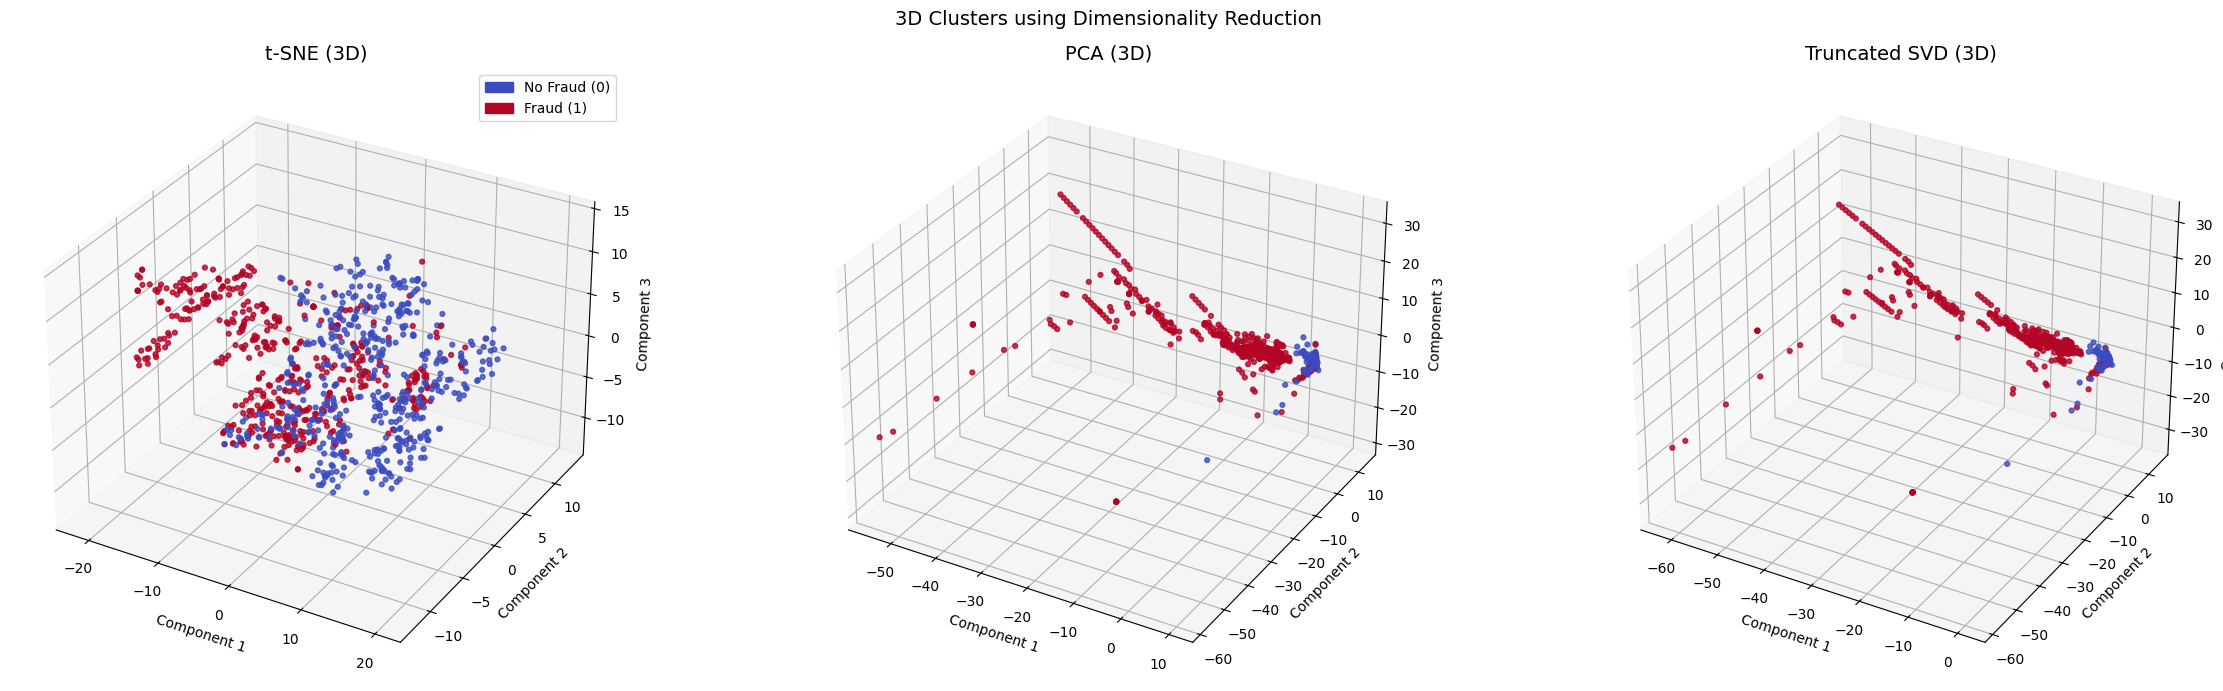

In [46]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

from sklearn.manifold import TSNE
from sklearn.decomposition import PCA, TruncatedSVD

# -------------------------
# Data (balanced/undersampled)
# -------------------------
X = sampled_df.drop("Class", axis=1).values
y = sampled_df["Class"].astype(int).values

# Optional: if you ever run this on a much bigger df, subsample for speed:
# n = min(len(y), 3000)
# idx = np.random.RandomState(42).choice(len(y), size=n, replace=False)
# X, y = X[idx], y[idx]

# -------------------------
# 3D Dimensionality reduction
# -------------------------
t0 = time.time()
X_tsne_3d = TSNE(
    n_components=3,
    random_state=42,
    init="pca",
    learning_rate="auto",
    perplexity=30,  # must be < n_samples
).fit_transform(X)
print(f"t-SNE (3D) took {time.time() - t0:.2f} s")

t0 = time.time()
X_pca_3d = PCA(n_components=3, svd_solver="randomized", random_state=42).fit_transform(X)
print(f"PCA (3D) took {time.time() - t0:.2f} s")

t0 = time.time()
X_svd_3d = TruncatedSVD(n_components=3, algorithm="randomized", random_state=42).fit_transform(X)
print(f"TruncatedSVD (3D) took {time.time() - t0:.2f} s")

# -------------------------
# Plotting (3D)
# -------------------------
fig = plt.figure(figsize=(24, 7))
fig.suptitle("3D Clusters using Dimensionality Reduction", fontsize=14)

ax1 = fig.add_subplot(1, 3, 1, projection="3d")
ax2 = fig.add_subplot(1, 3, 2, projection="3d")
ax3 = fig.add_subplot(1, 3, 3, projection="3d")

def plot3d(ax, X3d, y, title):
    ax.scatter(
        X3d[:, 0], X3d[:, 1], X3d[:, 2],
        c=y, cmap="coolwarm", s=12, alpha=0.8
    )
    ax.set_title(title, fontsize=14)
    ax.set_xlabel("Component 1")
    ax.set_ylabel("Component 2")
    ax.set_zlabel("Component 3")
    ax.grid(True)

plot3d(ax1, X_tsne_3d, y, "t-SNE (3D)")
plot3d(ax2, X_pca_3d,  y, "PCA (3D)")
plot3d(ax3, X_svd_3d,  y, "Truncated SVD (3D)")

# Simple legend matching the colormap endpoints
no_fraud_color = plt.cm.coolwarm(0.0)
fraud_color = plt.cm.coolwarm(1.0)
legend_handles = [
    Patch(color=no_fraud_color, label="No Fraud (0)"),
    Patch(color=fraud_color, label="Fraud (1)"),
]
ax1.legend(handles=legend_handles, loc="best")

plt.tight_layout()
plt.show()

### Feature-level seperation ranking

In [49]:
import pandas as pd
from sklearn.metrics import roc_auc_score

y = scaled_df["Class"].astype(int)
features = [c for c in scaled_df.columns if c != "Class"]

rows = []
for c in features:
    auc = roc_auc_score(y, scaled_df[c])
    # if feature is inversely related, AUC could be < 0.5; flip it so "strength" is visible
    strength = max(auc, 1 - auc)
    rows.append((c, auc, strength))

auc_df = pd.DataFrame(rows, columns=["feature", "roc_auc", "strength"]).sort_values("strength", ascending=False)
print(auc_df.head(5))
print(auc_df.tail(5))

   feature   roc_auc  strength
15     V14  0.050840  0.949160
5       V4  0.938258  0.938258
13     V12  0.062960  0.937040
12     V11  0.918083  0.918083
11     V10  0.085943  0.914057
   feature   roc_auc  strength
24     V23  0.465125  0.534875
26     V25  0.532548  0.532548
14     V13  0.474604  0.525396
16     V15  0.480252  0.519748
23     V22  0.514477  0.514477


### Split strategy

In [ ]:
# Split the data to train, val, test with stratify
from sklearn.model_selection import train_test_split

def make_splits(df, *, test_size=0.2, val_size=0.2, random_state=42):
    df = df.copy()
    df["Class"] = df["Class"].astype(int)

    X = df.drop(columns=["Class"])
    y = df["Class"]

    X_trainval, X_test, y_trainval, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_trainval, y_trainval, test_size=val_size, random_state=random_state, stratify=y_trainval
    )
    return X_train, X_val, X_test, y_train, y_val, y_test

X_train, X_val, X_test, y_train, y_val, y_test = make_splits(scaled_df)

### Feature stability across splits

In [56]:
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.inspection import permutation_importance
from sklearn.metrics import average_precision_score

from xgboost import XGBClassifier


# ---------- data ----------
X = scaled_df.drop(columns=["Class"])
y = scaled_df["Class"].astype(int)

def ap_scorer(estimator, X, y):
    # Average Precision (PR-AUC) using predicted probabilities for class 1
    proba = estimator.predict_proba(X)[:, 1]
    return average_precision_score(y, proba)

def make_xgb(scale_pos_weight: float) -> XGBClassifier:
    return XGBClassifier(
        n_estimators=800,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        min_child_weight=1.0,
        gamma=0.0,
        scale_pos_weight=scale_pos_weight,
        tree_method="hist",
        n_jobs=-1,
        random_state=42,
        eval_metric="aucpr",
        verbosity=0,
    )

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold_importances = []
fold_scores = []

for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y), start=1):
    X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
    y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

    n_pos = int(y_tr.sum())
    n_neg = int((y_tr == 0).sum())
    spw = n_neg / max(n_pos, 1)

    model = make_xgb(spw)
    model.fit(X_tr, y_tr)

    # PR-AUC on this fold’s validation set
    proba_va = model.predict_proba(X_va)[:, 1]
    pr_auc = average_precision_score(y_va, proba_va)
    fold_scores.append(pr_auc)
    print(f"Fold {fold}: PR-AUC={pr_auc:.6f}")

    # Permutation importance (PR-AUC drop when feature is shuffled)
    pi = permutation_importance(
        model,
        X_va, y_va,
        scoring=ap_scorer,
        n_repeats=5,
        random_state=fold,
        n_jobs=-1
    )

    imp = pd.Series(pi.importances_mean, index=X.columns, name=f"fold_{fold}")
    fold_importances.append(imp)

imp_df = pd.concat(fold_importances, axis=1)

summary = pd.DataFrame({
    "mean_importance": imp_df.mean(axis=1),
    "std_importance": imp_df.std(axis=1),
})
summary["cv"] = summary["std_importance"] / (summary["mean_importance"].abs() + 1e-12)
summary = summary.sort_values("mean_importance", ascending=False)

print("\nPR-AUC across folds:", [round(s, 6) for s in fold_scores])

print("\nTop 15 important features (mean permutation importance):")
print(summary.head(15))

print("\nMost unstable among the top 30 (higher cv = more unstable):")
print(summary.head(30).sort_values("cv", ascending=False).head(10))

Fold 1: PR-AUC=0.853301
Fold 2: PR-AUC=0.896288
Fold 3: PR-AUC=0.880842
Fold 4: PR-AUC=0.859341
Fold 5: PR-AUC=0.826790

PR-AUC across folds: [0.853301, 0.896288, 0.880842, 0.859341, 0.82679]

Top 15 important features (mean permutation importance):
               mean_importance  std_importance        cv
V14                   0.074438        0.031577  0.424210
V4                    0.050095        0.009463  0.188902
V12                   0.031596        0.010460  0.331064
V3                    0.012247        0.004686  0.382621
scaled_amount         0.010653        0.002300  0.215927
V11                   0.010079        0.003746  0.371671
V1                    0.008422        0.002712  0.322046
V8                    0.007220        0.003966  0.549319
V10                   0.005469        0.009111  1.665892
V28                   0.005078        0.003529  0.694909
V26                   0.004671        0.004154  0.889255
V19                   0.004333        0.002042  0.471267
V15      

### Base Model

In [50]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import average_precision_score, roc_auc_score, confusion_matrix, classification_report

# ---------- 2) Class imbalance weight ----------
n_pos = int(y_train.sum())
n_neg = int((y_train == 0).sum())
scale_pos_weight = n_neg / max(n_pos, 1)
print("Train positives:", n_pos, "Train negatives:", n_neg, "scale_pos_weight:", scale_pos_weight)

# ---------- 3) Train XGBoost ----------
# pip install xgboost  (if needed)
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=5000,
    learning_rate=0.03,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    min_child_weight=1.0,
    gamma=0.0,
    scale_pos_weight=scale_pos_weight,

    eval_metric="aucpr",
    early_stopping_rounds=200,

    tree_method="hist",
    n_jobs=-1,
    random_state=42,
)

xgb.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=200
)

# ---------- 4) Evaluate ----------
def evaluate(model, X, y, *, threshold=0.5, name="Eval"):
    proba = model.predict_proba(X)[:, 1]

    pr_auc = average_precision_score(y, proba)
    roc_auc = roc_auc_score(y, proba)

    pred = (proba >= threshold).astype(int)
    cm = confusion_matrix(y, pred)

    print(f"\n{name}")
    print(f"PR-AUC  : {pr_auc:.6f}")
    print(f"ROC-AUC : {roc_auc:.6f}")
    print(f"Threshold: {threshold}")
    print("Confusion matrix:\n", cm)
    print(classification_report(y, pred, digits=4))

    return proba

_ = evaluate(xgb, X_val,  y_val,  threshold=0.5, name="XGB (Val)")
proba_test = evaluate(xgb, X_test, y_test, threshold=0.5, name="XGB (Test)")

# ---------- 5) Feature importance ----------
imp = pd.Series(xgb.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print("\nTop 20 features:")
print(imp.head(20))

Train positives: 315 Train negatives: 181961 scale_pos_weight: 577.6539682539683
[0]	validation_0-aucpr:0.12040
[200]	validation_0-aucpr:0.72823
[400]	validation_0-aucpr:0.80193
[600]	validation_0-aucpr:0.81953
[800]	validation_0-aucpr:0.82765
[1000]	validation_0-aucpr:0.83644
[1200]	validation_0-aucpr:0.84177
[1400]	validation_0-aucpr:0.84345
[1600]	validation_0-aucpr:0.84435
[1800]	validation_0-aucpr:0.84493
[2000]	validation_0-aucpr:0.84531
[2200]	validation_0-aucpr:0.84580
[2400]	validation_0-aucpr:0.84598
[2600]	validation_0-aucpr:0.84591
[2800]	validation_0-aucpr:0.84608
[2939]	validation_0-aucpr:0.84590

XGB (Val)
PR-AUC  : 0.846655
ROC-AUC : 0.973518
Threshold: 0.5
Confusion matrix:
 [[45484     6]
 [   16    63]]
              precision    recall  f1-score   support

           0     0.9996    0.9999    0.9998     45490
           1     0.9130    0.7975    0.8514        79

    accuracy                         0.9995     45569
   macro avg     0.9563    0.8987    0.9256     45

### Picking thresholds

In [51]:
import numpy as np
from sklearn.metrics import precision_recall_curve, average_precision_score, roc_auc_score, confusion_matrix, classification_report

def pick_threshold_max_f1(y_true, proba):
    precision, recall, thresholds = precision_recall_curve(y_true, proba)
    # precision/recall have length = len(thresholds)+1
    f1 = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-12)
    best_idx = np.argmax(f1)
    return thresholds[best_idx], precision[best_idx], recall[best_idx], f1[best_idx]

def evaluate_at_threshold(y_true, proba, threshold, name="Eval"):
    preds = (proba >= threshold).astype(int)
    pr_auc = average_precision_score(y_true, proba)
    roc_auc = roc_auc_score(y_true, proba)

    print(f"\n{name}")
    print(f"PR-AUC  : {pr_auc:.6f}")
    print(f"ROC-AUC : {roc_auc:.6f}")
    print(f"Threshold: {threshold:.6f}")
    print("Confusion matrix:\n", confusion_matrix(y_true, preds))
    print(classification_report(y_true, preds, digits=4))

# --- get probabilities ---
proba_val  = xgb.predict_proba(X_val)[:, 1]
proba_test = xgb.predict_proba(X_test)[:, 1]

# --- choose threshold on validation (best F1) ---
thr, p, r, f1 = pick_threshold_max_f1(y_val.values if hasattr(y_val, "values") else y_val, proba_val)
print(f"Best threshold on VAL (max F1): {thr:.6f} | Precision={p:.4f} Recall={r:.4f} F1={f1:.4f}")

# --- evaluate on test using that threshold ---
evaluate_at_threshold(y_test.values if hasattr(y_test, "values") else y_test, proba_test, thr, name="TEST @ val-chosen threshold")

Best threshold on VAL (max F1): 0.968353 | Precision=0.9531 Recall=0.7722 F1=0.8531

TEST @ val-chosen threshold
PR-AUC  : 0.873509
ROC-AUC : 0.980676
Threshold: 0.968353
Confusion matrix:
 [[56859     5]
 [   19    79]]
              precision    recall  f1-score   support

           0     0.9997    0.9999    0.9998     56864
           1     0.9405    0.8061    0.8681        98

    accuracy                         0.9996     56962
   macro avg     0.9701    0.9030    0.9340     56962
weighted avg     0.9996    0.9996    0.9996     56962



In [52]:
def pick_threshold_recall_at_min_precision(y_true, proba, min_precision=0.10):
    precision, recall, thresholds = precision_recall_curve(y_true, proba)
    precision_t = precision[:-1]
    recall_t = recall[:-1]

    ok = precision_t >= min_precision
    if not np.any(ok):
        # no threshold reaches min precision
        best_idx = np.argmax(precision_t)
        return thresholds[best_idx], precision_t[best_idx], recall_t[best_idx]

    # among acceptable thresholds, pick highest recall
    idx = np.argmax(recall_t[ok])
    best_idx = np.where(ok)[0][idx]
    return thresholds[best_idx], precision_t[best_idx], recall_t[best_idx]

thr2, p2, r2 = pick_threshold_recall_at_min_precision(y_val, proba_val, min_precision=0.10)
print(f"VAL threshold (max recall with precision>=0.10): {thr2:.6f} | Precision={p2:.4f} Recall={r2:.4f}")

evaluate_at_threshold(y_test, proba_test, thr2, name="TEST @ precision-constrained threshold")

VAL threshold (max recall with precision>=0.10): 0.000116 | Precision=0.1000 Recall=0.8987

TEST @ precision-constrained threshold
PR-AUC  : 0.873509
ROC-AUC : 0.980676
Threshold: 0.000116
Confusion matrix:
 [[56025   839]
 [   10    88]]
              precision    recall  f1-score   support

           0     0.9998    0.9852    0.9925     56864
           1     0.0949    0.8980    0.1717        98

    accuracy                         0.9851     56962
   macro avg     0.5474    0.9416    0.5821     56962
weighted avg     0.9983    0.9851    0.9911     56962



### Calibration curve

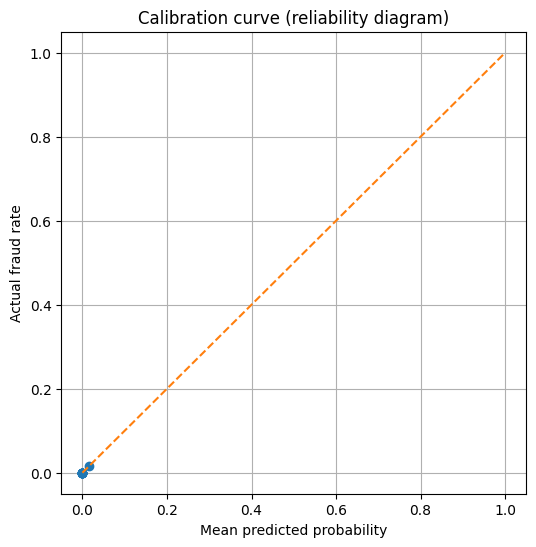

In [53]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

# proba_test = xgb.predict_proba(X_test)[:, 1]
y_true = y_test.values if hasattr(y_test, "values") else y_test

frac_pos, mean_pred = calibration_curve(y_true, proba_test, n_bins=10, strategy="quantile")

plt.figure(figsize=(6,6))
plt.plot(mean_pred, frac_pos, marker="o")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("Mean predicted probability")
plt.ylabel("Actual fraud rate")
plt.title("Calibration curve (reliability diagram)")
plt.grid(True)
plt.show()

### Top-K evaluation/alert-volume metrics

In [54]:
import numpy as np
import pandas as pd

def topk_metrics(y_true, proba, ks):
    y_true = np.asarray(y_true)
    proba = np.asarray(proba)

    order = np.argsort(-proba)  # descending by risk
    y_sorted = y_true[order]
    total_fraud = y_sorted.sum()

    rows = []
    cum_tp = np.cumsum(y_sorted)  # how many frauds caught up to rank k

    for k in ks:
        k = int(min(k, len(y_sorted)))
        tp = cum_tp[k-1]
        fp = k - tp
        precision = tp / max(k, 1)
        recall = tp / max(total_fraud, 1)
        rows.append((k, int(tp), int(fp), precision, recall))

    return pd.DataFrame(rows, columns=["alerts_k", "tp", "fp", "precision", "recall"])

# Example usage on validation set probabilities
# proba_val = xgb.predict_proba(X_val)[:, 1]
df_curve = topk_metrics(y_val, proba_val, ks=[50, 100, 200, 500, 1000, 2000])
print(df_curve)


   alerts_k  tp    fp  precision    recall
0        50  50     0      1.000  0.632911
1       100  66    34      0.660  0.835443
2       200  69   131      0.345  0.873418
3       500  71   429      0.142  0.898734
4      1000  71   929      0.071  0.898734
5      2000  72  1928      0.036  0.911392


### Error analysis (after a baseline model)

In [55]:
import pandas as pd
import numpy as np

# proba_test = xgb.predict_proba(X_test)[:, 1]
# choose a threshold (maybe your val-chosen threshold)
threshold = thr  # from your earlier threshold selection

test_df = X_test.copy()
test_df["y_true"] = y_test.values if hasattr(y_test, "values") else y_test
test_df["proba"] = proba_test
test_df["y_pred"] = (test_df["proba"] >= threshold).astype(int)

# make 10 amount bins
test_df["amount_bin"] = pd.qcut(test_df["scaled_amount"], q=10, duplicates="drop")

summary = test_df.groupby("amount_bin").apply(lambda g: pd.Series({
    "n": len(g),
    "fraud_rate": g["y_true"].mean(),
    "precision": ( (g["y_pred"]==1) & (g["y_true"]==1) ).sum() / max((g["y_pred"]==1).sum(), 1),
    "recall": ( (g["y_pred"]==1) & (g["y_true"]==1) ).sum() / max((g["y_true"]==1).sum(), 1),
    "fp": ((g["y_pred"]==1) & (g["y_true"]==0)).sum(),
    "fn": ((g["y_pred"]==0) & (g["y_true"]==1)).sum(),
})).reset_index()

print(summary)

         amount_bin       n  fraud_rate  precision    recall   fp   fn
0  (-0.308, -0.293]  6172.0    0.005833   0.882353  0.833333  4.0  6.0
1  (-0.293, -0.258]  5223.0    0.001340   1.000000  0.571429  0.0  3.0
2  (-0.258, -0.184]  5694.0    0.000878   1.000000  0.600000  0.0  2.0
3  (-0.184, -0.126]  5735.0    0.000697   1.000000  0.750000  0.0  1.0
4     (-0.126, 0.0]  5711.0    0.000175   1.000000  1.000000  0.0  0.0
5      (0.0, 0.209]  5644.0    0.000886   1.000000  0.600000  0.0  2.0
6     (0.209, 0.52]  5694.0    0.000527   1.000000  1.000000  0.0  0.0
7      (0.52, 1.09]  5708.0    0.002278   1.000000  0.846154  0.0  2.0
8     (1.09, 2.495]  5685.0    0.001407   1.000000  1.000000  0.0  0.0
9  (2.495, 180.101]  5696.0    0.002809   0.928571  0.812500  1.0  3.0


C:\Users\User\AppData\Local\Temp\ipykernel_15788\2632765324.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = test_df.groupby("amount_bin").apply(lambda g: pd.Series({
C:\Users\User\AppData\Local\Temp\ipykernel_15788\2632765324.py:16: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summary = test_df.groupby("amount_bin").apply(lambda g: pd.Series({
